In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
path = '/content/drive/Shareddrives/Time Series Group 5/Final_Project/data/monthly_counts/'
all_files = glob.glob(os.path.join(path, "*.csv"))

# Create a list of DataFrames by reading each CSV file
df_list = [pd.read_csv(filename) for filename in all_files]

# Concatenate all DataFrames in the list into a single DataFrame
monthly_rides = pd.concat(df_list, ignore_index=True).drop(columns=["Unnamed: 0"])

# Display the combined DataFrame
monthly_rides.head()

,month,num_trips
0,2024-01-01T00:00:00.000,425203
1,2024-02-01T00:00:00.000,440013
2,2024-03-01T00:00:00.000,524134
3,2024-04-01T00:00:00.000,546369
4,2024-05-01T00:00:00.000,619945


In [ ]:
monthly_rides["month"] = pd.to_datetime(monthly_rides["month"])
monthly_rides = monthly_rides.sort_values("month")

ts = monthly_rides.set_index("month")["num_trips"].asfreq("MS")

ts = ts.ffill()

ts.head(), ts.tail()

(month
 2013-01-01    1590062
 2013-02-01    1800402
 2013-03-01    2261377
 2013-04-01    2116671
 2013-05-01    2260977
 Freq: MS, Name: num_trips, dtype: int64,
 month
 2025-09-01    623661
 2025-10-01    641251
 2025-11-01    519892
 2025-12-01    552588
 2026-01-01        27
 Freq: MS, Name: num_trips, dtype: int64)

In [ ]:
h = 12
train, test = ts.iloc[:-h], ts.iloc[-h:]
train.shape, test.shape

((145,), (12,))

In [ ]:
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
).fit(optimized=True)

hw_model.summary()

Dep. Variable:,num_trips,No. Observations:,145
Model:,ExponentialSmoothing,SSE,2501229972616.611
Optimized:,True,AIC,3449.805
Trend:,Additive,BIC,3497.433
Seasonal:,Additive,AICC,3455.234
Seasonal Periods:,12,Date:,"Wed, 25 Feb 2026"
Box-Cox:,False,Time:,18:34:41
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9309095,alpha,True
smoothing_trend,0.000000,beta,True


In [ ]:
fc = hw_model.forecast(steps=h)
fc.index = test.index

mae = mean_absolute_error(test, fc)
rmse = np.sqrt(mean_squared_error(test, fc))

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

pd.DataFrame({"actual": test, "forecast": fc}).head(12)

MAE:  77,588.45
RMSE: 105,361.40


,actual,forecast
month,,
2025-02-01,449874,427263.902129
2025-03-01,562670,631104.900824
2025-04-01,577814,599922.295878
2025-05-01,651900,710557.772243
2025-06-01,646275,769015.854917
2025-07-01,589367,660776.120555
2025-08-01,585608,656068.976195
2025-09-01,623661,576503.802831
2025-10-01,641251,663039.165251


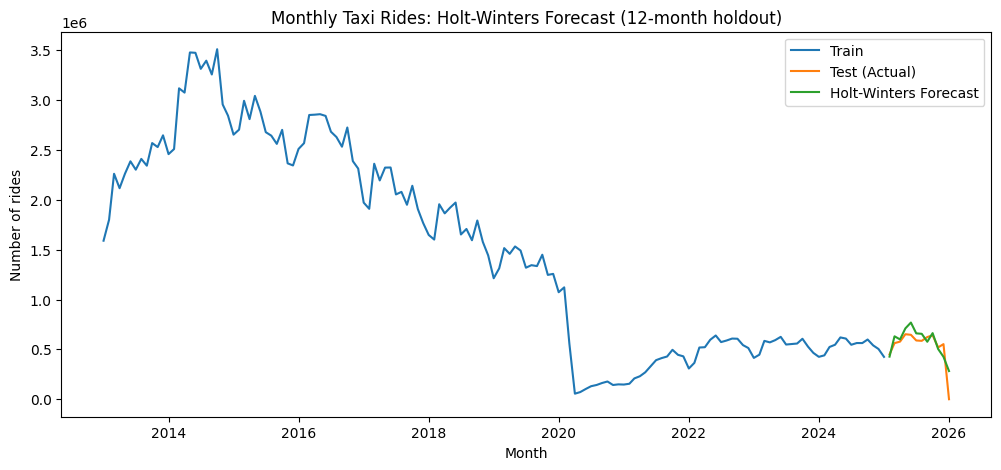

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test (Actual)")
plt.plot(fc.index, fc, label="Holt-Winters Forecast")
plt.title("Monthly Taxi Rides: Holt-Winters Forecast (12-month holdout)")
plt.xlabel("Month")
plt.ylabel("Number of rides")
plt.legend()
plt.show()

In [ ]:
test_new = test[test.index.year != 2026]
fc_new = hw_model.forecast(steps=len(test_new))
fc_new.index = test_new.index
mae_new = mean_absolute_error(test_new, fc_new)
rmse_new = np.sqrt(mean_squared_error(test_new, fc_new))

print(f"Filtered Test (drop 2026) | MAE: {mae_new:,.2f} | RMSE: {rmse_new:,.2f}")

pd.DataFrame({"actual": test_new, "forecast": fc_new}).head(12)

Filtered Test (drop 2026) | MAE: 58,948.06 | RMSE: 69,629.57


,actual,forecast
month,,
2025-02-01,449874,427263.902129
2025-03-01,562670,631104.900824
2025-04-01,577814,599922.295878
2025-05-01,651900,710557.772243
2025-06-01,646275,769015.854917
2025-07-01,589367,660776.120555
2025-08-01,585608,656068.976195
2025-09-01,623661,576503.802831
2025-10-01,641251,663039.165251


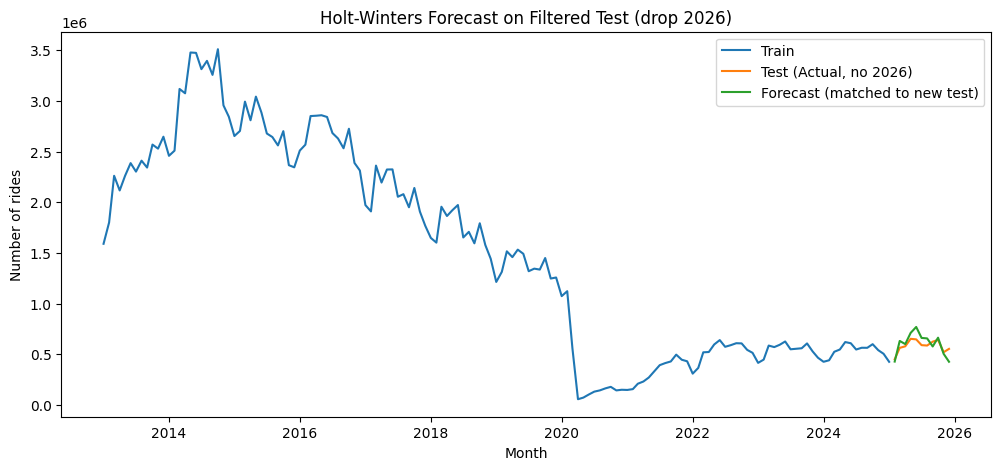

In [ ]:
# New Cell: plot using filtered test
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test_new.index, test_new, label="Test (Actual, no 2026)")
plt.plot(fc_new.index, fc_new, label="Forecast (matched to new test)")
plt.title("Holt-Winters Forecast on Filtered Test (drop 2026)")
plt.xlabel("Month")
plt.ylabel("Number of rides")
plt.legend()
plt.show()


In [ ]:
test_same = test_new.copy()

cutoff = pd.Timestamp("2020-03-01")
train_post = train[train.index >= cutoff]

print("Original train:", train.shape, "| Post-COVID train:", train_post.shape, "| Test:", test_same.shape)

hw_post = ExponentialSmoothing(
    train_post,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
).fit(optimized=True)

fc_post = hw_post.forecast(steps=len(test_same))
fc_post.index = test_same.index

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_post = mean_absolute_error(test_same, fc_post)
rmse_post = np.sqrt(mean_squared_error(test_same, fc_post))

print(f"Post-COVID HW | MAE: {mae_post:,.2f} | RMSE: {rmse_post:,.2f}")

pd.DataFrame({"actual": test_same, "forecast": fc_post}).head(12)

Original train: (145,) | Post-COVID train: (59,) | Test: (11,)
Post-COVID HW | MAE: 25,970.13 | RMSE: 33,946.53


,actual,forecast
month,,
2025-02-01,449874,456034.619968
2025-03-01,562670,575277.970979
2025-04-01,577814,561586.658387
2025-05-01,651900,602190.188769
2025-06-01,646275,643208.333426
2025-07-01,589367,613486.842491
2025-08-01,585608,625346.100778
2025-09-01,623661,633636.142980
2025-10-01,641251,659178.774092
